<a href="https://colab.research.google.com/github/lookmeebbear/Geoimg_SVCU/blob/main/GeoAI_GeoSAM_Yokky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Segmentation by Geospatial Segment Anything Model (GeoSAM)**


นำมาจาก Automatically generating object masks with SAM

Associate Professor Dr.Qiusheng Wu

https://samgeo.gishub.org/examples/automatic_mask_generator/


ลงเครื่องมือที่จำเป็น

In [ ]:
 %pip install segment-geospatial leafmap localtileserver

In [ ]:
import os
from google.colab import files
import leafmap
from samgeo import SamGeo, show_image, download_file, overlay_images, tms_to_geotiff

นำเข้าข้อมูลภาพทางภูมิศาสตร์

In [ ]:
imgRGB = '/content/yokky_crop1.tif'

นำเข้าโมเดลการสกัดวัตถุจากภาพ

In [ ]:
out_dir = os.path.join(os.path.expanduser("~"), "Downloads")
checkpoint = os.path.join(out_dir, "sam_vit_h_4b8939.pth")

In [ ]:
sam = SamGeo(
    model_type="vit_h",
    checkpoint=checkpoint,
    sam_kwargs=None,
)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:12<00:00, 199MB/s]


Segment Anything Model ....

In [ ]:
sam.generate(imgRGB, output="segment.jpg", foreground=True, unique=True)

Show the object annotations (objects with random color) on the map.

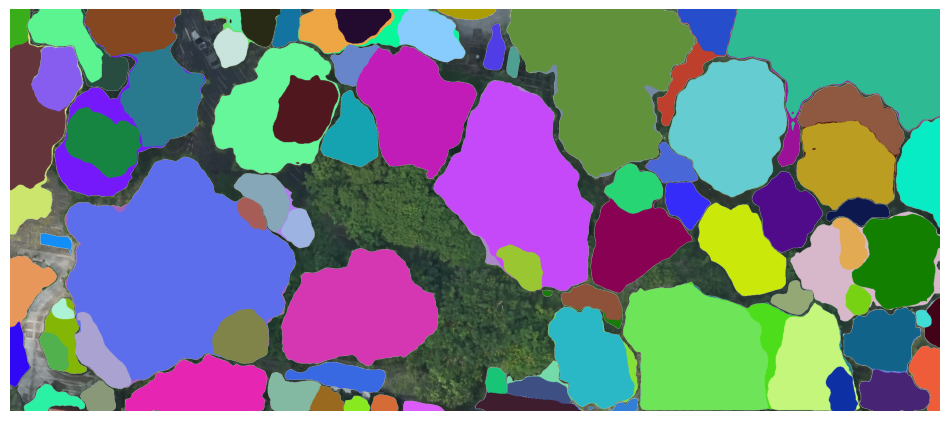

In [ ]:
sam.show_anns(axis="off", alpha=1, output="annotations.tif")

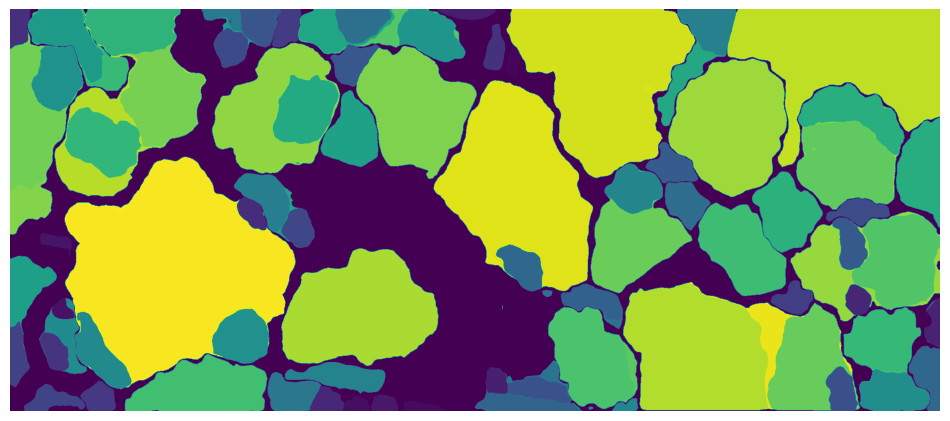

In [ ]:
sam.show_masks(cmap='viridis')

Compare images with a slider.


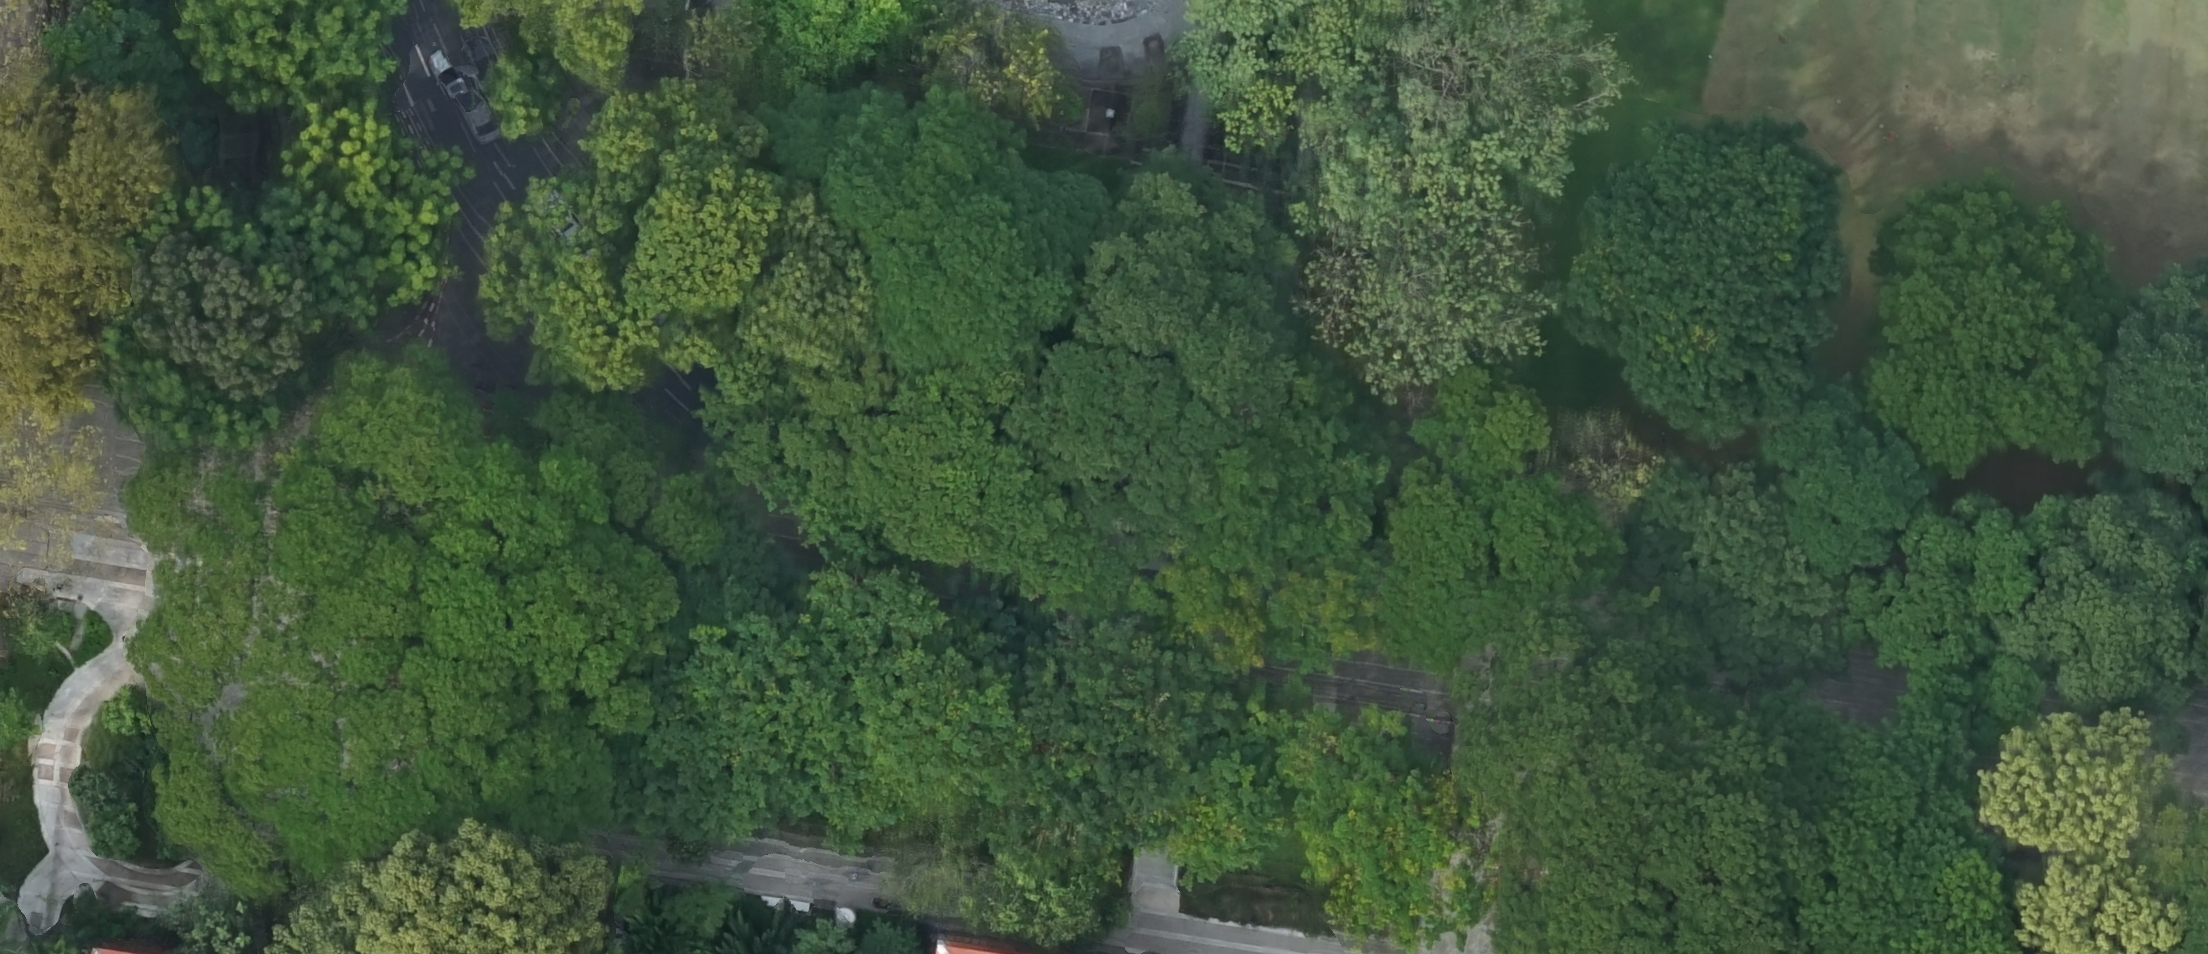
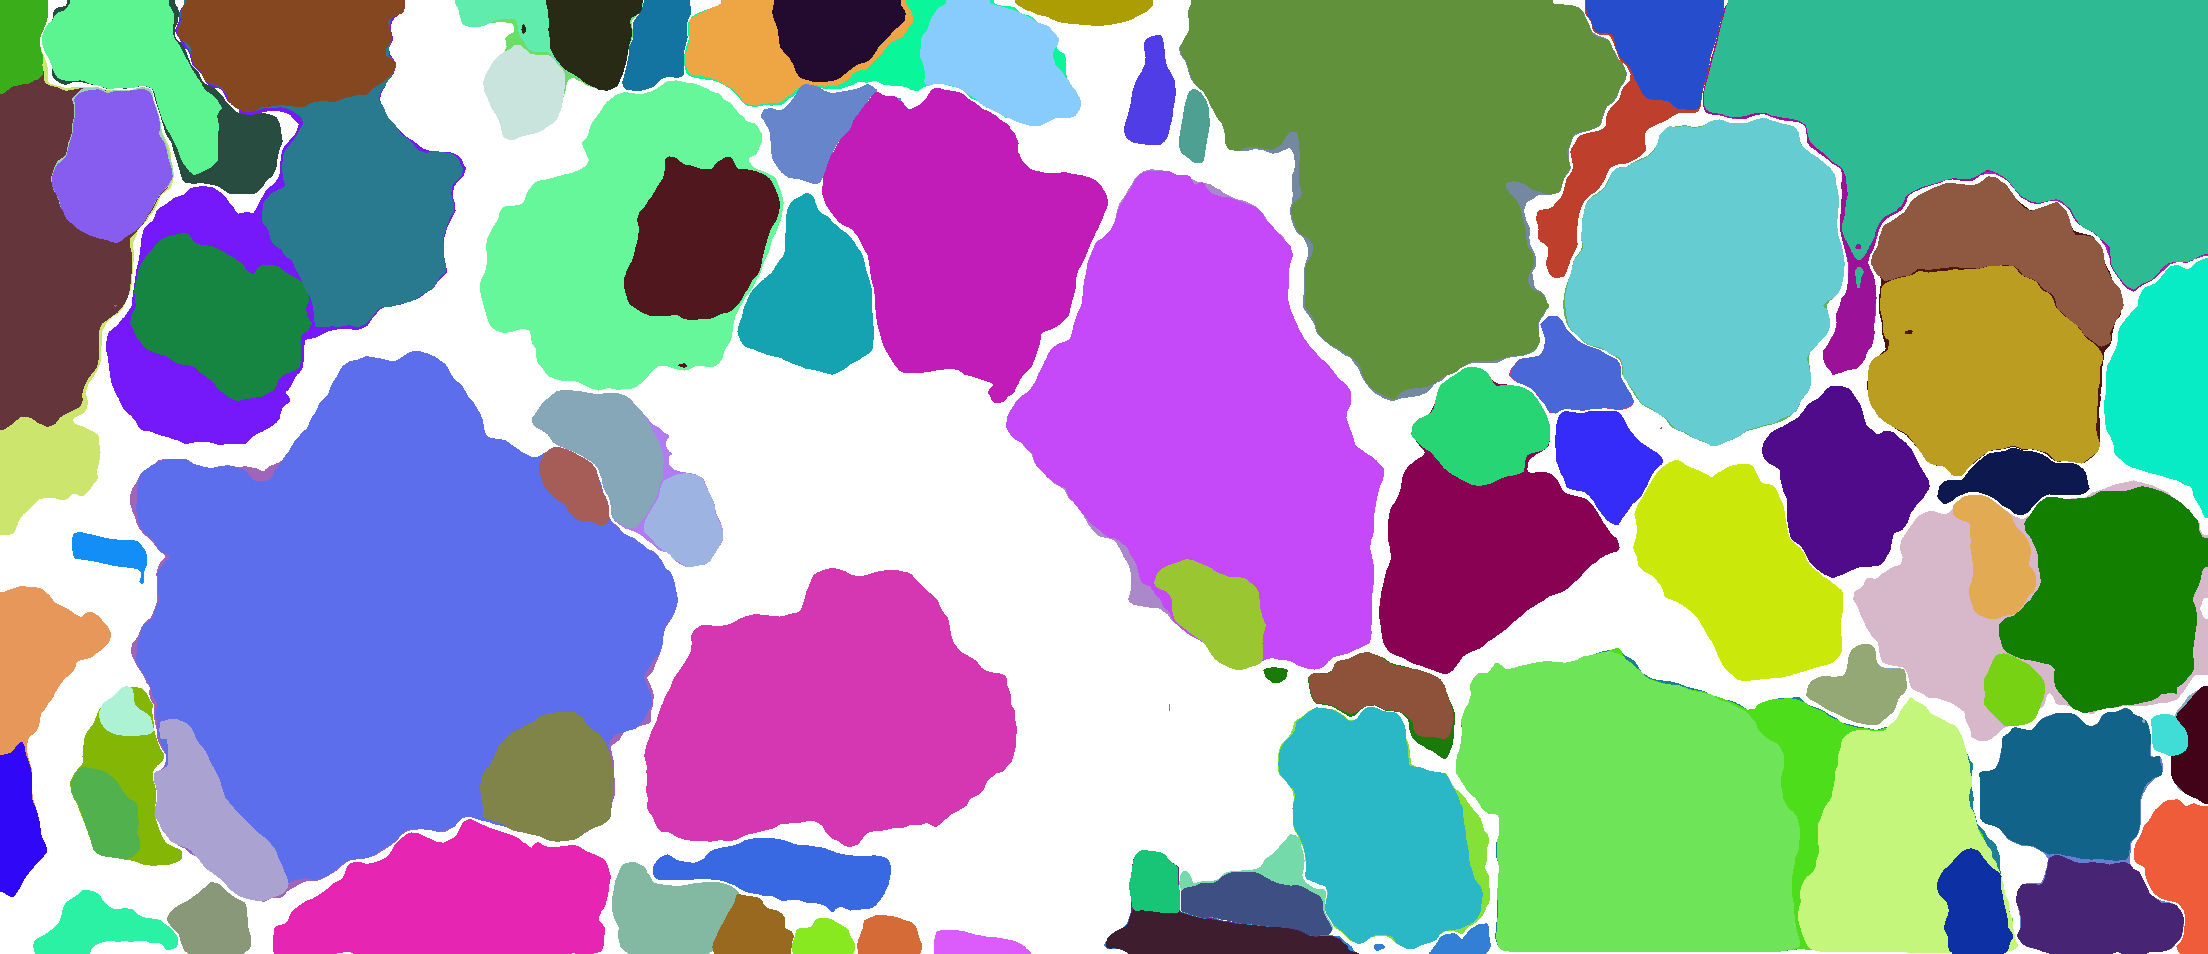

In [ ]:
leafmap.image_comparison(
    imgRGB,
    "annotations.tif",
    label1="yokky_orthophoto",
    label2="object_segmentation",
)

In [ ]:
sam.tiff_to_vector("annotations.tif", "segment1.gpkg")

Download the results

In [ ]:
files.download("segment1.gpkg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Let's prepare sample data ....

In [ ]:
import pandas as pd
import geopandas as gpd

In [ ]:
df = gpd.read_file('/content/segment_addband.gpkg')
df

,value,Red_median,Green_median,Blue_median,class,geometry
0,255.0,69.0,84.0,59.0,NaN,"POLYGON ((665434.798 1519284.992, 665434.798 1..."
1,9.0,76.0,89.0,84.0,NaN,"POLYGON ((665439.272 1519284.992, 665439.272 1..."
2,42.0,48.0,68.0,45.0,NaN,"POLYGON ((665408.469 1519284.992, 665408.469 1..."
3,193.0,90.0,101.5,82.0,NaN,"POLYGON ((665496.976 1519284.82, 665496.976 15..."
4,9.0,85.0,97.0,86.0,NaN,"POLYGON ((665454.702 1519284.992, 665454.702 1..."
...,...,...,...,...,...,...
1978,255.0,42.0,53.0,35.0,NaN,"POLYGON ((665430.725 1519230.328, 665430.725 1..."
1979,255.0,33.5,53.0,43.5,NaN,"POLYGON ((665438.755 1519230.443, 665438.755 1..."
1980,255.0,53.0,73.0,57.0,4.0,"POLYGON ((665421.146 1519284.992, 665421.146 1..."
1981,255.0,100.0,114.0,78.0,NaN,"POLYGON ((665519.289 1519230.386, 665519.289 1..."


In [ ]:
df_train = df[df['class'].notnull()]
df_train

,value,Red_median,Green_median,Blue_median,class,geometry
151,96.0,77.0,95.0,60.0,0.0,"POLYGON ((665424.014 1519284.992, 665424.014 1..."
226,35.0,62.0,96.0,55.0,4.0,"POLYGON ((665442.312 1519284.992, 665442.312 1..."
287,41.0,86.0,104.0,63.0,3.0,"POLYGON ((665429.234 1519284.992, 665429.234 1..."
289,19.0,48.0,59.0,54.0,4.0,"POLYGON ((665434.855 1519284.992, 665434.855 1..."
305,58.0,100.0,100.0,81.5,1.0,"POLYGON ((665397.915 1519284.992, 665397.915 1..."
...,...,...,...,...,...,...
1962,195.0,50.0,77.0,53.0,4.0,"POLYGON ((665507.53 1519245.012, 665507.53 151..."
1964,13.0,58.0,88.0,51.0,4.0,"POLYGON ((665510.914 1519236.351, 665510.914 1..."
1966,71.0,111.0,123.0,77.0,2.0,"POLYGON ((665515.733 1519235.95, 665515.733 15..."
1974,239.0,72.0,93.0,62.0,4.0,"POLYGON ((665522.673 1519239.162, 665522.673 1..."


Let's make ML model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
#from sklearn.model_selection import train_test_split

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
x = df_train[ ['Red_median',	'Green_median',	'Blue_median'] ]
y = df_train[ 'class' ]

In [ ]:
clf.fit(x, y)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(x)
y_pred

array([0., 4., 3., 4., 1., 4., 3., 0., 3., 4., 5., 4., 4., 1., 6., 6., 3.,
       6., 3., 3., 4., 4., 4., 3., 6., 3., 0., 4., 1., 3., 4., 4., 4., 4.,
       4., 1., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 0., 4., 4., 4.,
       2., 4., 4., 0., 4., 4., 4., 4., 4., 4., 2., 4., 4.])

In [ ]:
y_true = y.to_numpy()
y_true

array([0., 4., 3., 4., 1., 4., 3., 0., 3., 4., 5., 4., 4., 1., 6., 6., 3.,
       6., 3., 3., 4., 4., 4., 3., 6., 3., 0., 4., 1., 3., 4., 4., 4., 4.,
       4., 1., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 0., 4., 4., 4.,
       2., 4., 4., 0., 4., 4., 4., 4., 4., 4., 2., 4., 4.])

In [ ]:
confusion_matrix(y_true, y_pred)

array([[ 5,  0,  0,  0,  0,  0,  0],
       [ 0,  4,  0,  0,  0,  0,  0],
       [ 0,  0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  0, 39,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  4]])

In [ ]:
print( classification_report(y_true, y_pred) )

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         1.0       1.00      1.00      1.00         4
         2.0       1.00      1.00      1.00         2
         3.0       1.00      1.00      1.00         9
         4.0       1.00      1.00      1.00        39
         5.0       1.00      1.00      1.00         1
         6.0       1.00      1.00      1.00         4

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



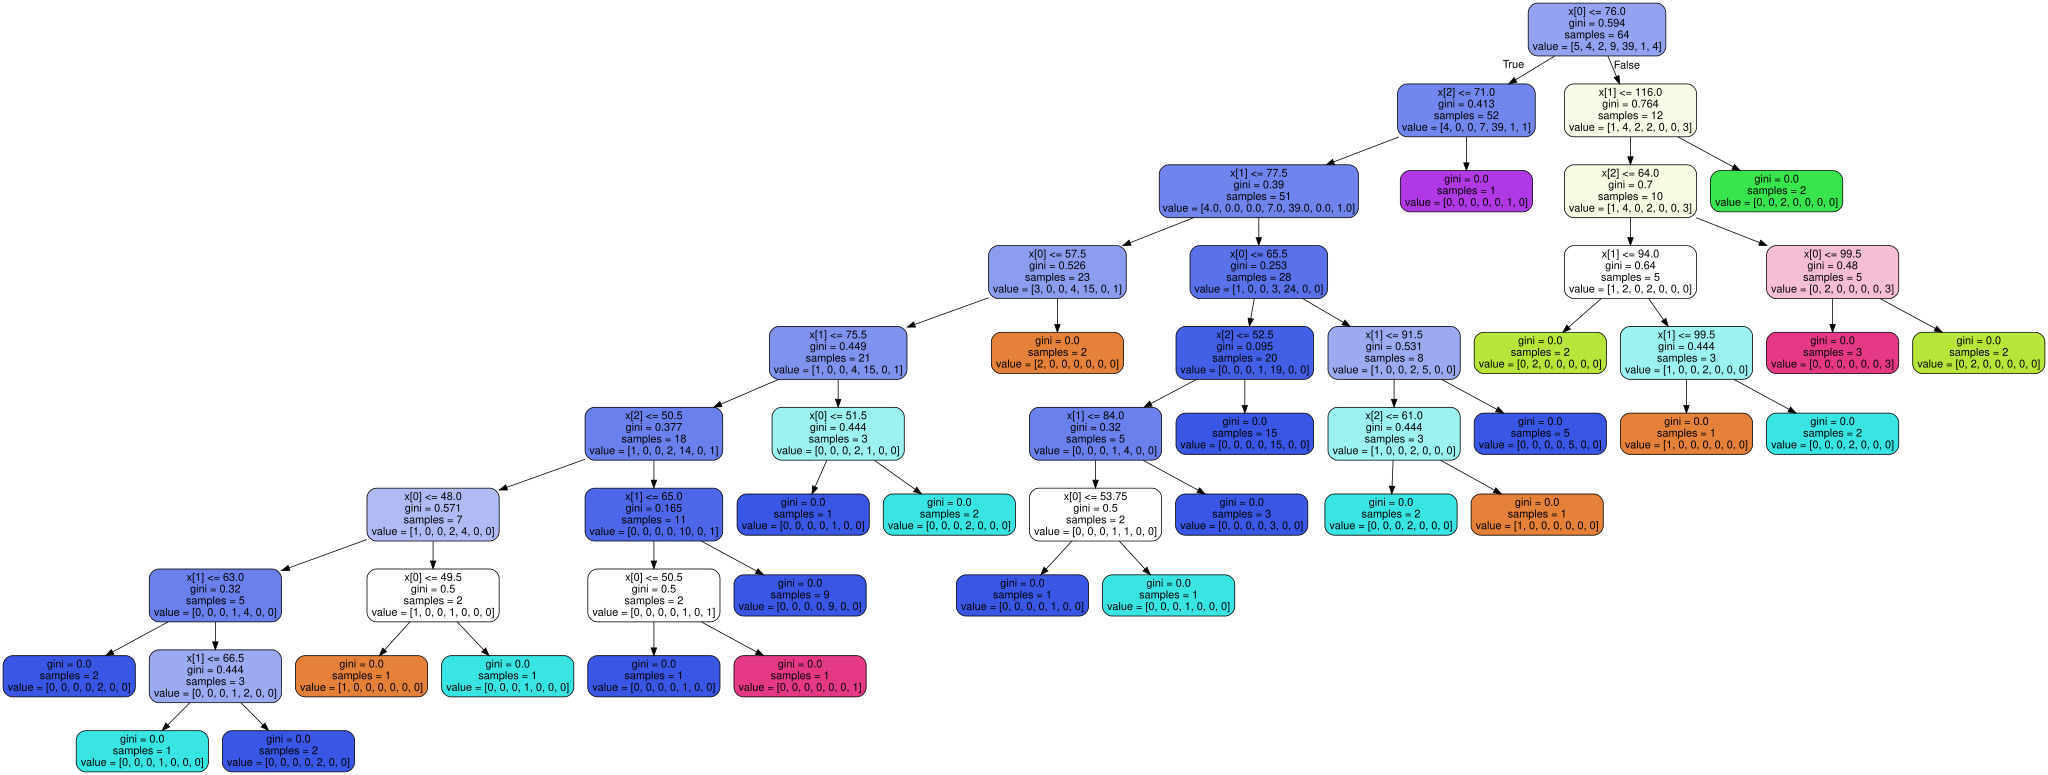

In [ ]:
import graphviz

# str(list(clf.classes_)[0]), str(list(clf.classes_)[1]), str(list(clf.classes_)[2])
dot_data = tree.export_graphviz(clf,
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
fie_ext = 'png'
temp_img = 'temp_file'
#my_graph = graphviz.Source(graph_data)
graph.render(temp_img,format=fie_ext, view=False)

'temp_file.png'

In [ ]:
import pickle
pickle.dump(clf, open('mymodel.pkl','wb') )

In [ ]:
loaded_model = pickle.load(open('mymodel.pkl', 'rb'))

In [ ]:
def predict_class( feat ):
  return loaded_model.predict( feat )

In [ ]:
df.apply(predict_class, lambda x: f(x.col_1, x.col_2), axis=1)

In [ ]:
pred_all = clf.predict( df[ ['Red_median',	'Green_median',	'Blue_median'] ] )
pred_all

array([3., 5., 4., ..., 4., 1., 3.])

In [ ]:
df['pred_class'] = pred_all
df

,value,Red_median,Green_median,Blue_median,class,geometry,pred_class
0,255.0,69.0,84.0,59.0,NaN,"POLYGON ((665434.798 1519284.992, 665434.798 1...",3.0
1,9.0,76.0,89.0,84.0,NaN,"POLYGON ((665439.272 1519284.992, 665439.272 1...",5.0
2,42.0,48.0,68.0,45.0,NaN,"POLYGON ((665408.469 1519284.992, 665408.469 1...",4.0
3,193.0,90.0,101.5,82.0,NaN,"POLYGON ((665496.976 1519284.82, 665496.976 15...",6.0
4,9.0,85.0,97.0,86.0,NaN,"POLYGON ((665454.702 1519284.992, 665454.702 1...",6.0
...,...,...,...,...,...,...,...
1978,255.0,42.0,53.0,35.0,NaN,"POLYGON ((665430.725 1519230.328, 665430.725 1...",4.0
1979,255.0,33.5,53.0,43.5,NaN,"POLYGON ((665438.755 1519230.443, 665438.755 1...",4.0
1980,255.0,53.0,73.0,57.0,4.0,"POLYGON ((665421.146 1519284.992, 665421.146 1...",4.0
1981,255.0,100.0,114.0,78.0,NaN,"POLYGON ((665519.289 1519230.386, 665519.289 1...",1.0


In [ ]:
df.to_file('segment_predict.gpkg', driver='GPKG')